# Predicting the Unpredictable
## Task 3: Storm Event Classification Report

##Introduction

In this task, we create a model to classify storm events as either `Thunderstorm Wind`, `Hail`, `Flash Flood`, `Flood`, `Tornado`, `Heavy Rain`, `Lightning`, or `Funnel Cloud` in a multi-class classification problem. The input of our model are 36 frame sequences of remote sensing images across 4  channels (`vis`, `ir069`, `ir107`, `vil`) and the output is a single label corresponding to a specific storm event classification.

<br>

Challenges of constructing this multi-class classification model include the multidimensional data inputs that include height, width, time, and multiple channels with differing resolutions. Additionally, classification can be difficult when trying to distinguish similar looking events such as tornados and funnel clouds. Class imbalance will also be addressed as models may prioritize correctly labelling majority classes to minimize loss.

<br>

Our goal is to build a Deep Learning model (specifically a 3D CNN) to effectively extract features from these event sequences and classify each event as the correct storm type. We will begin with a baseline model, analyze its performance metrics, and  implement extensions to address the class imbalance and improve generalization. We adopt an iterative development strategy:
1.  **Baseline:** Establish initial performance using a standard 3D CNN.
2.  **Extension 1 (Weighted Loss):** Address class imbalance by penalizing misclassification of underrepresented events.
3.  **Extension 2 (Data Augmentation):** Improve generalization and robustness by artificially increasing dataset diversity (rotations and flips).
4.  **Extension 3 (Optimization):** Refine training dynamics using Learning Rate Scheduling to prevent overfitting.

##Data Exploration

We analyzed the dataset to understand the distribution of event categories and the structure of the input data. This step is crucial for identifying potential biases and determining necessary preprocessing.

**Key Observations:**
1.  **Class Imbalance:** As shown in the bar chart below, the dataset is heavily skewed. "Thunderstorm Wind" and "Hail" are the dominant classes, while "Funnel Cloud", "Lightning", and "Heavy Rain" are rarer. We will need to ensure that all classes are represented in training and validation and can take preprocessing steps to balance the datasteps. Moreover, it inidcates that accuracy alone can be a misleading metric for model performance.
2.  **Resolution Mismatch:** The sample storms show that the two IR channels ($192 \times 192$) have half the spatial resolution of the VIS and VIL channels ($384 \times 384$). These must be upscaled or the VIS and VIL must be downscales to match the dimensions of the other channels before we can stack them into a single 4-channel tensor.
3. **Value Differences:** Each sensor channel has an extremely varied starting range of values (e.g., VIS pixel values are about $200-12000$, while VIL values are $0-255$) that will not be conducive to training the model. We must decide how to scale each of the sensor channels to make the values comparable.


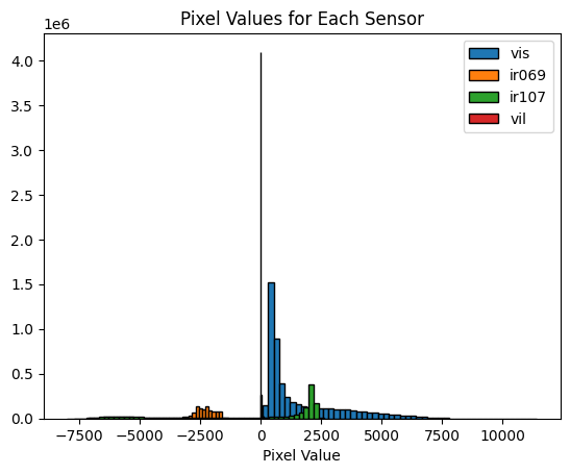

##  Data Preprocessing and Splitting

To address the issues identified in the exploration phase, we utilize our encapsulated `Task3Dataset` and preprocessing pipeline.

**Preprocessing Pipeline:**
* **Upsampling:** The `ir069` and `ir107` channels are bilinearly interpolated from $192 \times 192$ to $384 \times 384$ to match the VIS/VIL dimensions. We chose to upscale so we would not lose fine details from the VIS/VIL sensors.
* **Normalization:** Based on the variable ranges observed above, we apply channel-specific normalization (Log-scaling for VIL, MinMax/Z-score for others) to standardize inputs to a $[0, 1]$ range.
* **Stacking:** The 4 channels are stacked to create a tensor of shape $(36, 4, 384, 384)$.


**Data Splitting:**
Given the severe class imbalance, we use a Stratified Shuffle Split (grouped by Storm ID) to set aside 20% of the data for validation.  The Stratified Shuffle Split guarantees that all classes are represented in the validation set. We chose an 80/20 training split to give out model a larger portion of training data, as correctly classifying 8 storm types will be challenging.



##Metrics
Given the class imbalance, accuracy alone is a misleading metric. A model could achieve ~42% accuracy simply by predicting "Thunderstorm Wind" for every single input, yet it would fail to detect any tornadoes or floods.

We will track two primary metrics:
1.  **Validation Accuracy:** This gives a general sense of correctness.
2.  **Macro F1-Score:** This calculates the F1 score for each class independently and then takes the average. This treats all classes equally, meaning the model is heavily penalized if it fails on rare classes like "Funnel Cloud".

We utilize the helper functions from our package `predicting_unpredictable.metrics` to compute these during training.



##Baseline Model

We have selected a Simple 3D CNN as our baseline based on two primary reasons:

1.  **Spatiotemporal Feature Extraction:** Unlike standard 2D CNNs, which process images statically, a 3D CNN uses three-dimensional kernels $(Time \times Height \times Width)$. This allows the model to simultaneously learn spatial features like the shape of clouds and temporal features such as the movement of a storm cell. Capturing this evolution is critical for distinguishing events.
2.  **Complexity:** We intentionally design a shallow architecture (3 layers) to establish benchmark model. This helps us determine if the task requires additonal layers based on analysis of loss overfitting/underfitting behavior.

### Experiment Configuration
We employ the `CNN3d` class from our package with the following setup:

* **Architecture:** It consists of 3 blocks of **3D Convolutions** (kernel size $3 \times 3 \times 3$), each followed by **Batch Normalization**, **ReLU** activation, and **3D Max Pooling**. The network concludes with **Global Average Pooling** to flatten the temporal and spatial dimensions, feeding into a single Linear classifier. ReLu was chosen as the activation function due to the data normalization between 0 and 1 and ReLU's popularity with computer vision tasks.
* **Input Dimensions:** $(Batch, Time, Channel, Height, Width)$. The model internally permutes this to the PyTorch-standard $(B, C, T, H, W)$.
* **Loss Function:** Standard `CrossEntropyLoss` (Unweighted).
  * Works well for multi-class classification and uses strong penalization for incorrect classifications.
* **Optimizer:** Adam (`lr=1e-3`).
  * Popular optimizer and learning rate.

We will now train this baseline model for 10 epochs to observe its initial behavior, specifically looking for signs of the "accuracy paradox" caused by class imbalance. This is when  a model demonstrates high accuracy by predicting the majority class, but fails to predict minority class events.

Baseline Best Validation F1: 0.1926

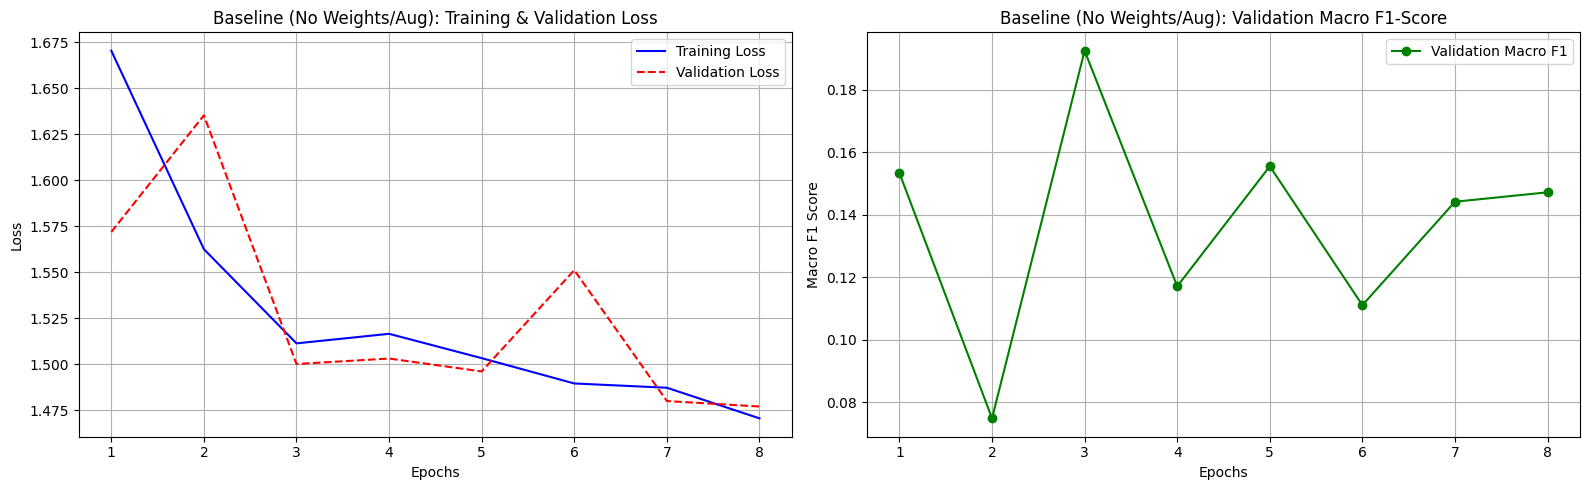

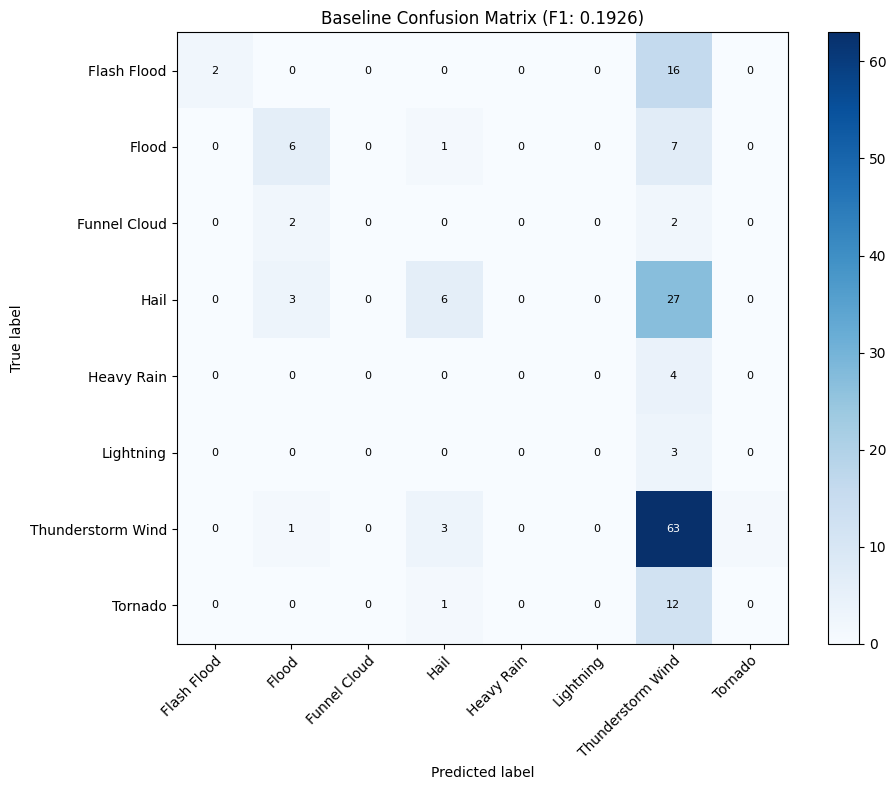

### Baseline Results Interpretation

<u>The Accuracy Paradox:</u>
While the model achieved a  peak Validation Accuracy of ~48.13% at Epoch 3, the Macro F1-Score remained critically low at 0.1926.
* The low Macro F1-score confirms that the model essentially fails to generalize, ignoring the underrepresented classes.

The Confusion Matrix provides visual proof of this bias. We observe a prominent vertical band corresponding to the "Thunderstorm Wind" class. The model overwhelmingly predicts the overrepresented class.
Underrepresented classes like "Lightning" and "Funnel Cloud" have a recall of zero, as the model fails to distinguish them from the dominant wind events.

<br>

The CNN3d architecture functions correctly (the pipeline works), but the model has learned the dataset's prior distribution rather than robust spatiotemporal features. To correct this, we introduce Class-Weighted Loss to penalize neglecting rarer events.

## Extension 1: Weighted Loss

To combat the class imbalance confirmed by the Baseline's failure, we introduce a **Weighted Cross-Entropy Loss**. Standard Cross-Entropy treats every sample equally, rarely classifying events as the underrepresented classes. We assign a higher penalty weight to rare classes, ensuring that misclassifying a rare class results in a much larger loss and stronger gradient update than misclassifying an overrepresented event.

<br>

We calculate the weight $w_c$ for each class $c$ using the inverse frequency strategy relative to the majority class:
$$w_c = \frac{N_{max}}{N_c}$$
where $N_{max}$ is the count of the most frequent class, and $N_c$ is the count of class $c$.
For example, if "Thunderstorm Wind" has 339 samples and "Tornado" has 67, the weight for Tornado will be $339/67 \approx 5.06$. This means the model pays $\approx 5\times$ more attention to Tornadoes.


We expect the Macro F1-score to improve significantly, as the model will no longer be able to ignore rare classes to minimize the loss.

Weighted Model Best Validation F1: 0.2654

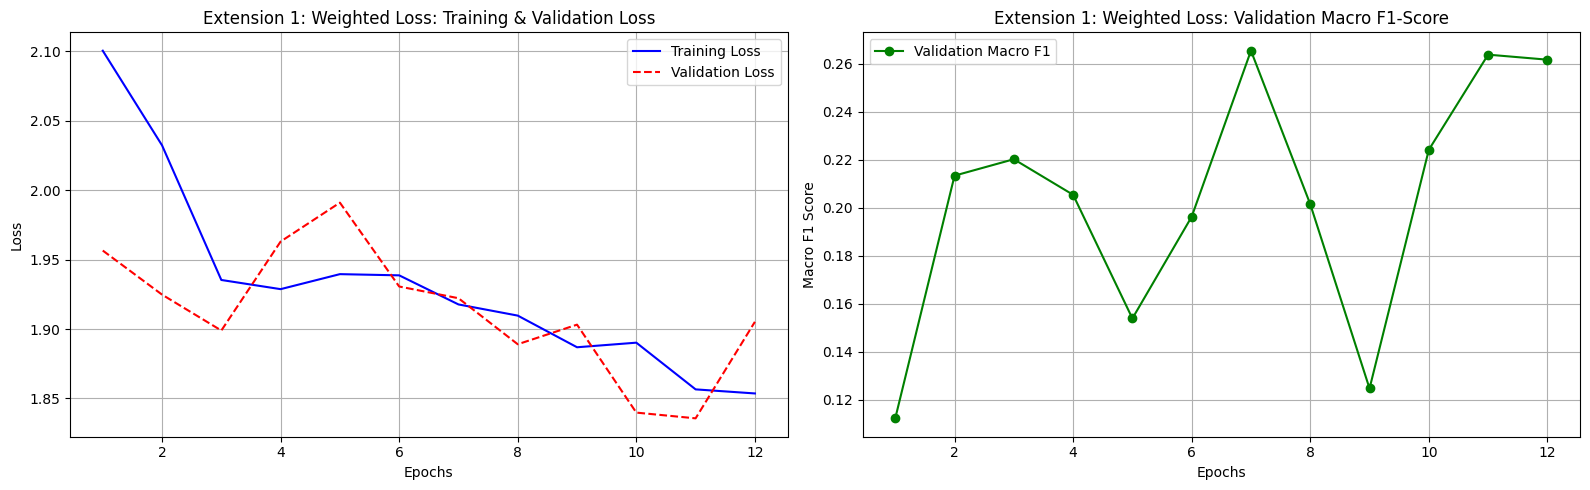

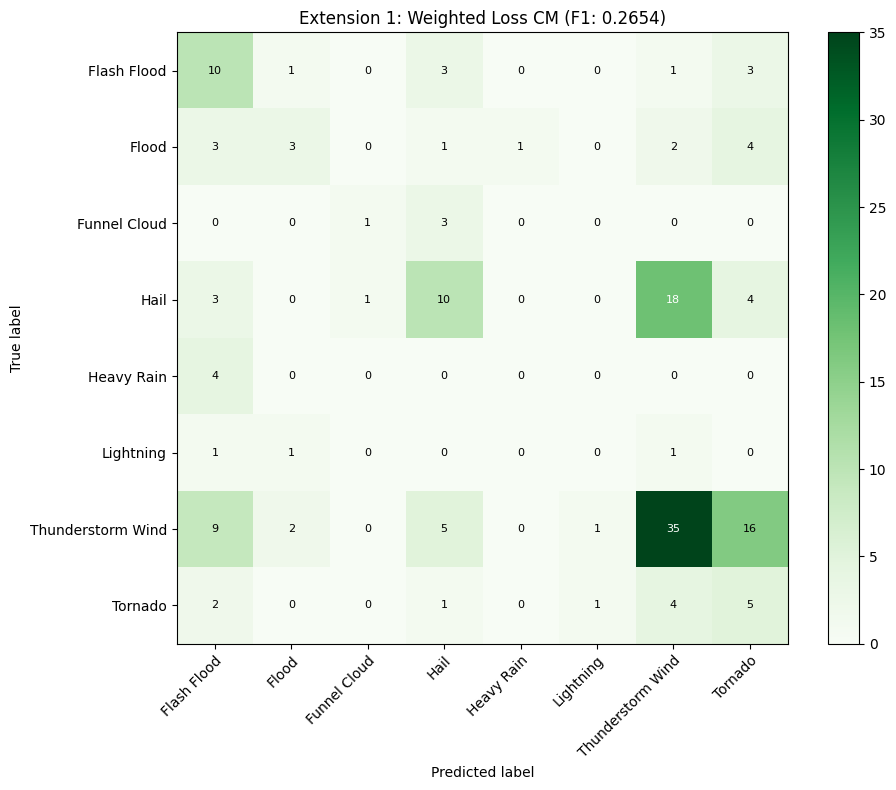

### Extension 1 Results Interpretation

The Validation Macro F1-score rose to 0.2654, a significant improvement over the baseline's 0.1926. This indicates that the model is trading off some overall accuracy to better identify minority events.

<br>

Comparing the new confusion matrix to the baseline:
*  The distinct vertical "Thunderstorm Wind" band is no longer present. The model is now distributing predictions across other categories rather than defaulting to the majority class.
* Minority Class Recognition:
    * **Tornado:** The model correctly identified **5 Tornadoes** (previously 0).
    * **Flash Flood:** Correct predictions jumped from 2 to **10**.
    * **Hail:** Correct predictions increased to **10** (previously 6).
    * **Funnel Cloud:** The model successfully detected **1** instance (previously 0).

For rare classes like "Lightning" and "Heavy Rain" (where recall remains 0), the model still struggles due to the sheer lack of training examples. To address this, we introduce Data Augmentation to artificially increase our dataset size and diversity.

##  Model Extension 2: Data Augmentation

The model still suffers from overfitting on classes due to the small sample size. To improve generalization, we implement Data Augmentation. Meteorological features are generally recognizable if they are roatated or flipped.
We modify the training pipeline to apply the following random transformations to the input tensor during training:
1.  **Random Rotation:** 0, 90, 180, or 270 degrees.
2.  **Random Flip:** Horizontal and/or Vertical flips.

**Configuration:**
* `use_weighted_loss = True` (Combine with class weights)
* `augment_data = True` (Enable transformations)
* `epochs = 20` (Data augmentation increases the effective dataset size, requiring sufficient epochs for convergence).

Augmented Model Best Validation F1: 0.2707

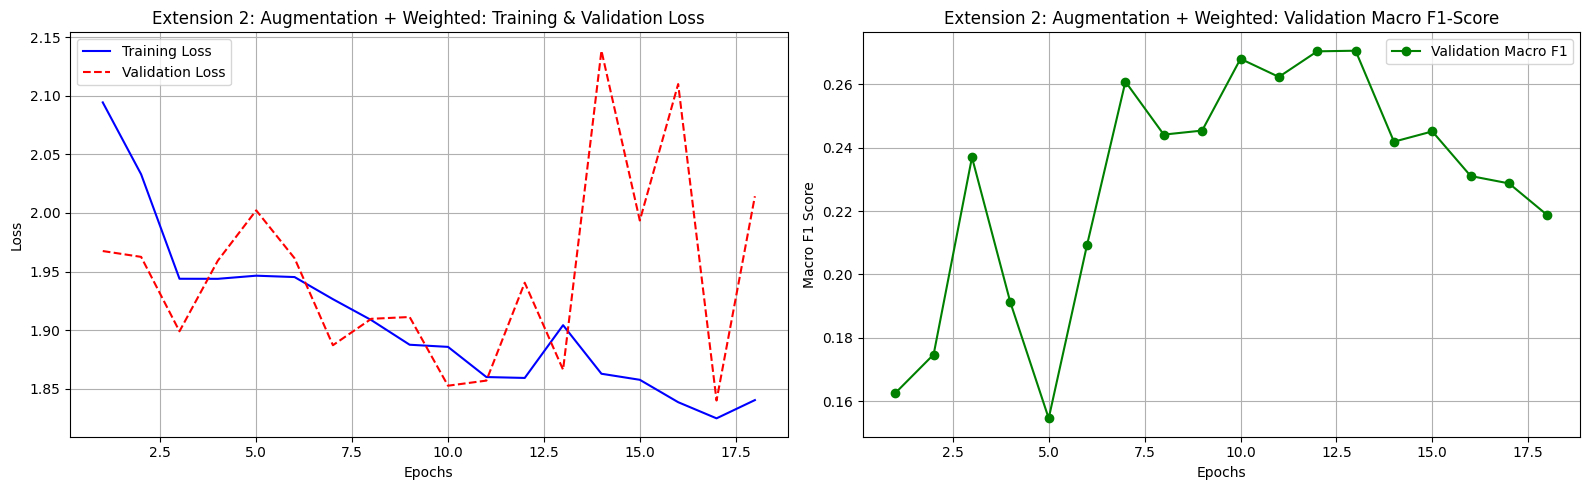

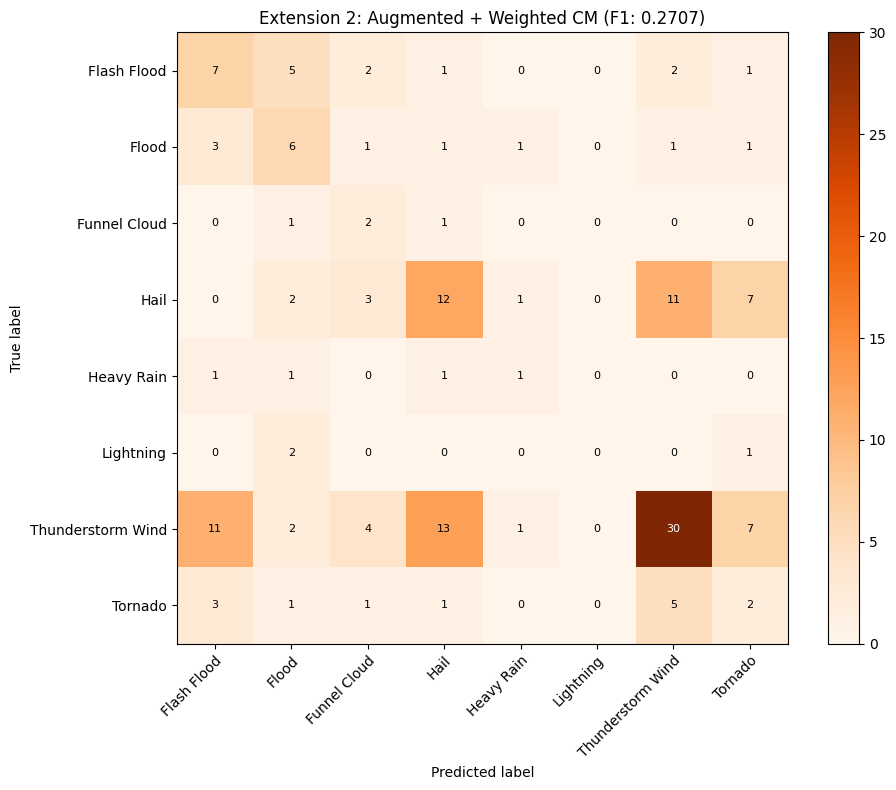

### Extension 2 Results Interpretation


Data Augmentation further improved the Macro F1-score to 0.2707 with extended training time (converged in 18 epochs), indicating it  learned robust physical features rather than just memorizing pixel patterns.

We successfully addressed Class Imbalance (via Weighted Loss) and Data Scarcity (via Augmentation). However, looking at the training plots, we observe spikes and fluctuations in the Validation Loss. To fix this, we try a Learning Rate Scheduler*.

## Model Extension 3: Learning Rate Scheduler

Throughout our experiments, we observed jagged fluctuations in the validation loss, indicating that the Learning Rate (LR) is too high as the model approaches the optimal solution.

We implement a ReduceLROnPlateau scheduler.
* The scheduler monitors the `validation_loss`. If the loss stops improving for a defined 'patience' period, it automatically reduces the learning rate by a factor of 0.1.
*  This allows the model to take smaller, more precise steps to find the best possible weights without overshooting.

**Configuration:**
* `use_weighted_loss = True`
* `augment_data = True`
* `use_scheduler = True`
* `epochs = 25` (Increased to give the scheduler time to decrease the LR for convergence).

Scheduler Model Best Validation F1: 0.3381

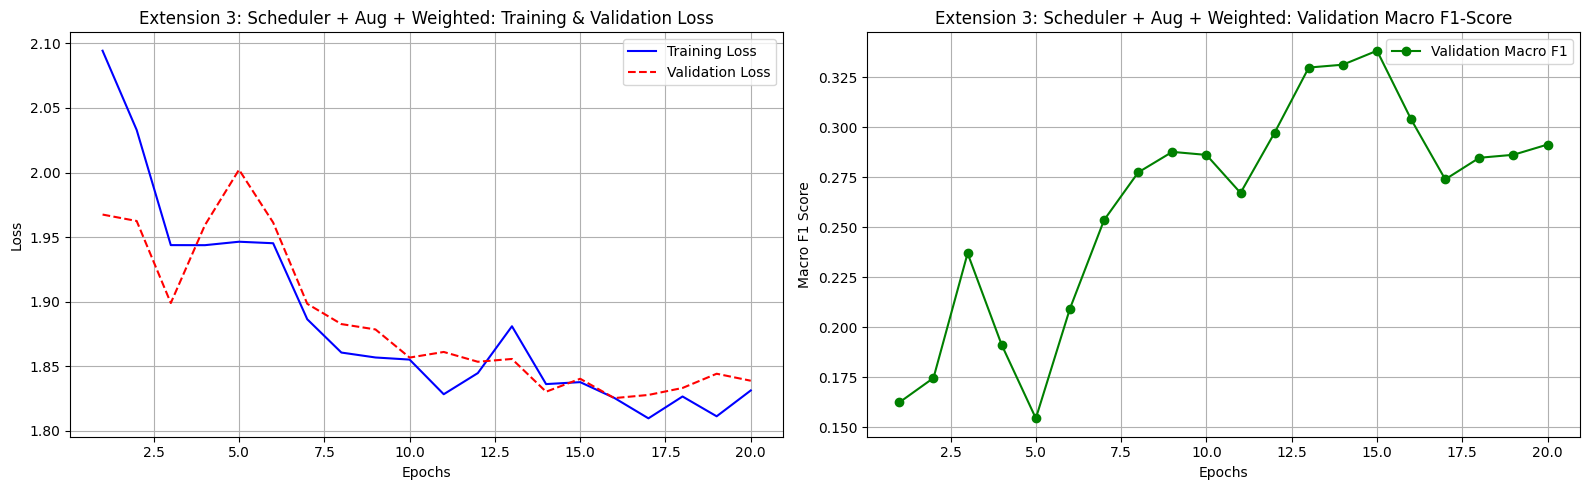

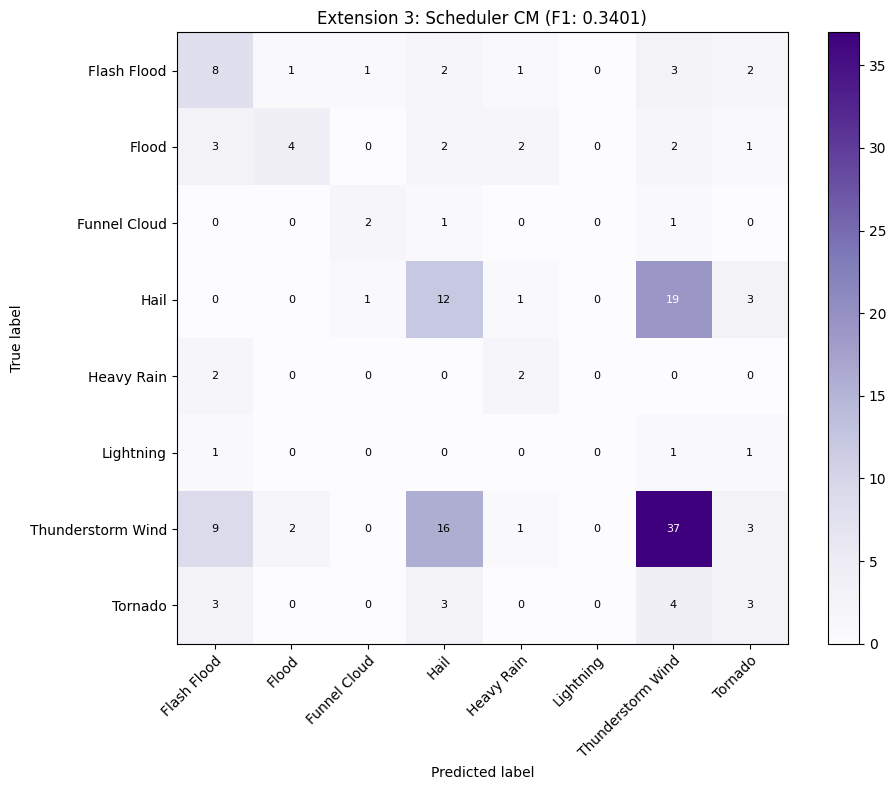

### Extension 3 Results Interpretation


The addition of the `ReduceLROnPlateau` scheduler resulted in the most significant performance leap since the introduction of class weights. The Validation Macro F1-score reached 0.3381 (at Epoch 15).

* This confirms our hypothesis that the constant learning rate ($1e^{-3}$) was preventing the model from reaching a better minimum. By decreasing the learning rate when loss plateaued, the model was able to fine-tune its weights, minimizing the overshooting behavior observed in previous experiments.
Unlike previous experiments where the best model was often found very early (e.g., Epoch 3), this model showed a healthy learning curve.
* The combination of Augmentation (making the task harder) and the Scheduler (allowing longer, finer training) enabled the model to learn progressively rather than memorizing noise early on.
* The Validation Loss stabilized around ~1.82, avoiding the spikes seen in the non-scheduled runs.

<br>

The model still has some issues with distinguishing between Thunderstorm Wind and Hail, which should be addressed in future work.

## Discussion (Final Model Analysis):

By systematically addressing **Class Imbalance** (Weighted Loss), **Overfitting/Invariance** (Data Augmentation), and **Optimization Volatility** (LR Scheduler), we have transformed a biased baseline that mostly guessed "Thunderstorm Wind" into a robust classifier with an F1 score of **0.3381**.

For future work, we could look into how classifying would change with dropping or masking the vis channel, as there are many events that occur with little information in the vis channel. Moreover, additional layers or a more complex model arcitecture such as a ResNet can be beneficial for the difficult task of classifying 8 types of weather events. Including dropout of overrepresented classes can also help to create a more robust model.

## Bonus Task: Explainability

The results of the final model gives insight into the model's workings and the challenge of classifying different storm events. The confusion matrix demonstrates the model's difficulty in distinguishing between Thunderstorm Wind and Hail, which can largely be explained by their overrepresentation in the dataset and their physical similarities. Because these are the two most common event types, the model is more likely to classify events into these two categories as it tries to maximize accuracy. Additionally, when visually inspecting these events they appear quite physically similar, both events appear to have some circular clouds moving together in a relatively linear path. The largest difference appears to be the size of the cloud clusters, with the Thunderstorm Wind clouds usually being larger than the Hail clouds.